In [1]:
import pandas as pd
import numpy as np
import pyBedGraph
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import seaborn as sns

In [2]:
compartment_path = '/nfs/turbo/umms-hammou/minjilab/juicer/work_mm10_backup/all_samples_combined/mega/aligned/compartments/flipped_compartments_250000_pc1_mm39.bedGraph'
compartments = pd.read_csv(compartment_path, sep='\t', header=None, names=['chrom', 'start', 'end', 'score'])

In [3]:
bg_folder = "/nfs/turbo/umms-hammou/minjilab/juicer/histone_bedgraph_fragments"
earliest_bg_path = bg_folder + "/D34_RS_H4ac.bedGraph"
early_bg_path = bg_folder + "/D34_ES_H4ac.bedGraph"

earliest_H3k27me3_bg_path = bg_folder + "/D34_RS_H3K27me3.bedGraph"
early_H3k27me3_bg_path = bg_folder + "/D34_ES_H3K27me3.bedGraph"

In [4]:
peaks_dir = "/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/Cut_Tag/A8538/25950R_histone/Peaks"
earliest_peaks_path = peaks_dir + "/D34_RS_H4ac.narrowPeak"
early_peaks_path = peaks_dir + "/D34_ES_H4ac.narrowPeak"

# load peak files as dataframes
earliest_peaks = pd.read_csv(earliest_peaks_path, sep='\t', header=None,
                             names=['chrom', 'start', 'end', 'name', 'score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak'])
early_peaks = pd.read_csv(early_peaks_path, sep='\t', header=None,
                         names=['chrom', 'start', 'end', 'name', 'score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']) 


# create region lists from peak dataframes efficiently
earliest_regions = earliest_peaks[['chrom', 'start', 'end']].astype({'start': int, 'end': int}).values.tolist()
early_regions = early_peaks[['chrom', 'start', 'end']].astype({'start': int, 'end': int}).values.tolist()

In [5]:
mm39_cs = "/nfs/turbo/umms-hammou/minjilab/juicer/references/mm39/mm39.chrom.sizes"
chrom_sizes = pd.read_csv(mm39_cs, sep="\t", header=None, names=["chrom", "size"])

In [6]:
from concurrent.futures import ProcessPoolExecutor

def process_chromosome(args):
    """
    Annotate windows for a single chromosome with compartment information and signal values.

    Args:
        args: Tuple containing:
            - chrom: Chromosome name (str)
            - chrom_windows: DataFrame of windows for this chromosome (columns: chrom, start, end)
            - chrom_comps: DataFrame of compartment regions for this chromosome (columns: chrom, start, end, score)
            - chrom_sizes_path: Path to chromosome sizes file (str)
            - bedgraph_path: Path to bedGraph file with signal (str)
            - stat: Statistic to compute from pyBedGraph ('max', 'mean', etc.)

    Returns:
        DataFrame with columns: chrom, start, end, stat_signal, compartment
        - stat_signal: Computed signal value for each window
        - compartment: 'A' if compartment score > 0, else 'B'
    
    Notes:
        - Uses pyBedGraph to extract signal for each window.
        - Merges windows with compartment regions using merge_asof (by chrom and start).
        - Only keeps windows fully contained within a compartment region.
    """
    chrom, chrom_windows, chrom_comps, chrom_sizes_path, bedgraph_path, stat = args
    chrom_windows = chrom_windows.sort_values(['start']).reset_index(drop=True)
    chrom_comps = chrom_comps.sort_values(['start']).reset_index(drop=True)
    bg = pyBedGraph.BedGraph(chrom_sizes_path, bedgraph_path, min_value=-100)
    bg.load_chrom_data(chrom)
    regions = chrom_windows[['chrom', 'start', 'end']].astype({'start': int, 'end': int}).values.tolist()
    chrom_windows['stat_signal'] = bg.stats(stat, regions)
    annotated = pd.merge_asof(
        chrom_windows, chrom_comps,
        by='chrom',
        left_on='start', right_on='start',
        direction='backward',
        suffixes=('', '_comp')
    )
    annotated = annotated[annotated['end'] <= annotated['end_comp']]
    annotated['compartment'] = annotated['score'].apply(lambda x: 'A' if x > 0 else 'B')
    return annotated[['chrom', 'start', 'end', 'stat_signal', 'compartment']]


def max_signal_by_compartment_parallel(chrom_sizes_path, windows_df, bedgraph_path, compartment_path, stat='max', n_jobs=4):
    """
    Computes signal statistics (e.g., max, mean) for genomic windows, annotates each window with compartment (A/B),
    and processes each chromosome in parallel.

    Args:
        chrom_sizes_path: Path to chromosome sizes file (str)
        windows_df: DataFrame of windows to analyze (columns: chrom, start, end)
        bedgraph_path: Path to bedGraph file with signal (str)
        compartment_path: Path to compartment bedGraph file (str)
        stat: Statistic to compute from pyBedGraph ('max', 'mean', etc.)
        n_jobs: Number of parallel processes to use (int)

    Returns:
        DataFrame with columns: chrom, start, end, stat_signal, compartment
    """
    compartments = pd.read_csv(compartment_path, sep="\t", header=None, names=["chrom", "start", "end", "score"])
    valid_chroms = set(compartments["chrom"])
    windows_df = windows_df[windows_df["chrom"].isin(valid_chroms)].copy()
    all_args = []
    for chrom in sorted(windows_df['chrom'].unique()):
        chrom_windows = windows_df[windows_df['chrom'] == chrom].copy()
        chrom_comps = compartments[compartments['chrom'] == chrom].copy()
        if chrom_windows.empty or chrom_comps.empty:
            continue
        all_args.append((chrom, chrom_windows, chrom_comps, chrom_sizes_path, bedgraph_path, stat))
    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        results = list(executor.map(process_chromosome, all_args))
    return pd.concat(results, ignore_index=True)


In [7]:
def plot_compartment_boxplot(
    df,
    column="stat_signal",
    by="compartment",
    title="Max Signal by Compartment",
    bins="1kb",
    ylim=(0,2),
    threshold=-1,
    annotate_p=False,
    fig1_save_name=None,
    fig2_save_name=None
):
    """
    Plot a boxplot (and optionally ECDF) comparing a signal column between two compartments (A/B).

    Args:
        df (pd.DataFrame): Input DataFrame containing signal and compartment columns.
        column (str): Name of the column with signal values to plot.
        by (str): Name of the column indicating compartment ('A' or 'B').
        title (str): Title for the plot.
        bins (str): Bin size or label for y-axis.
        ylim (tuple): y-axis limits for the boxplot.
        threshold (float): Minimum value for signal to include in plot.
        annotate_p (bool): If True, perform KS test and annotate p-value, and plot ECDF.
        fig1_save_name (str or None): If provided, save boxplot to this file.
        fig2_save_name (str or None): If provided, save ECDF plot to this file.

    Returns:
        None. Displays and optionally saves plots.
    """
    # Filter out rows below the threshold for plotting
    tmp = df[df[column] > threshold]
    if annotate_p:
        # Extract values for each compartment
        a_vals = tmp[tmp[by] == 'A'][column]
        b_vals = tmp[tmp[by] == 'B'][column]
        # Perform Kolmogorov-Smirnov test between compartments
        ks_stat, pval = ks_2samp(a_vals, b_vals)
        n_a, n_b = len(a_vals), len(b_vals)

    plt.figure(figsize=(8,6))
    palette = {'A': '#9900cd', 'B': '#e6ac00'}

    # Draw boxplot for each compartment
    ax = sns.boxplot(
        data=tmp,
        x=by,
        y=column,
        hue=by,
        palette=palette,
        showfliers=False,
        width=0.6
    )
    sns.despine()
    # Set plot title, optionally with KS test results
    if annotate_p:
        ax.set_title(f"{title}\nKS stat={ks_stat:.2e}, p={pval:.2e}", fontsize=14)
    else:
        ax.set_title(title, fontsize=14)

    # Set axis labels and limits
    ax.set_xlabel(by.capitalize(), fontsize=14)
    ax.set_ylabel(f"ATAC GC residual Signal ({bins})", fontsize=14)
    ax.set_ylim(*ylim)
    ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=7)
    ax.tick_params(axis='both', which='minor', width=2, length=4)
    
    # Annotate legend with sample sizes
    group_labels = [f"A (n={n_a})", f"B (n={n_b})"]
    handles = [plt.Line2D([0], [0], color=palette[label], lw=4) for label in ['A', 'B']]
    ax.legend(handles, group_labels, title=by.capitalize(),
              title_fontsize=18, fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    plt.tight_layout()
    # Save boxplot if filename provided
    if fig1_save_name:
        plt.savefig(fig1_save_name, dpi=300, bbox_inches='tight')
    plt.show()

    # If requested, plot ECDFs and annotate KS statistic
    if annotate_p:
        # Compute ECDF for a given array
        def ecdf(data):
            x = np.sort(data)
            y = np.arange(1, len(x)+1) / len(x)
            return x, y

        x_a, y_a = ecdf(a_vals)
        x_b, y_b = ecdf(b_vals)
        # Combine all unique x values for interpolation
        all_x = np.sort(np.unique(np.concatenate([x_a, x_b])))
        # Interpolate ECDFs to all_x for direct comparison
        y_a_interp = np.interp(all_x, x_a, y_a, left=0, right=1)
        y_b_interp = np.interp(all_x, x_b, y_b, left=0, right=1)
        diff = np.abs(y_a_interp - y_b_interp)
        max_idx = np.argmax(diff)
        ks_x = all_x[max_idx]
        ks_y1 = y_a_interp[max_idx]
        ks_y2 = y_b_interp[max_idx]

        plt.figure(figsize=(8,6))
        # Plot ECDF for compartment A
        plt.step(x_a, y_a, where="post", label=f"A (n={n_a})", color=palette['A'], linewidth=3)
        # Plot ECDF for compartment B
        plt.step(x_b, y_b, where="post", label=f"B (n={n_b})", color=palette['B'], linewidth=3)
        # Draw dashed line for KS max difference
        plt.plot([ks_x, ks_x], [ks_y1, ks_y2], color='black', linestyle='--', lw=2, label='KS max diff')
        plt.scatter([ks_x], [ks_y1], color=palette['A'])
        plt.scatter([ks_x], [ks_y2], color=palette['B'])
        plt.xlabel(f"ATAC Signal (GC residual)", fontsize=14)
        plt.ylabel("Cumulative Proportion", fontsize=14)
        plt.title(f"ECDFs for {title}\nKS stat={ks_stat:.2e}, p={pval:.2e}", fontsize=16)
        plt.tick_params(axis='both', which='major', labelsize=14, width=2, length=7)
        plt.tick_params(axis='both', which='minor', width=2, length=4)
        plt.legend(title=by.capitalize(), title_fontsize=18, fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
        plt.tight_layout()
        # Save ECDF plot if filename provided
        if fig2_save_name:
            plt.savefig(fig2_save_name, dpi=300, bbox_inches='tight')
        plt.show()

## Supp Fig 6d

### ATAC Coverage at H4ac Peaks

In [8]:
df_merged = pd.read_csv('analysis_data/mm39_merged_gc_resids_with_compartment_scores.csv', index_col=0)[['chrom', 'start', 'end', 'earliest_ES', 'early_ES']]
df_merged.head()

/tmp/ipykernel_4135925/1936618709.py:1: DtypeWarning: Columns (12,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv('analysis_data/mm39_merged_gc_resids_with_compartment_scores.csv', index_col=0)[['chrom', 'start', 'end', 'earliest_ES', 'early_ES']]


,chrom,start,end,earliest_ES,early_ES
0,chr1,0,1000,1.620047,2.328808
1,chr1,1000,2000,1.620047,2.328808
2,chr1,2000,3000,1.620047,2.328808
3,chr1,3000,4000,1.620047,2.328808
4,chr1,4000,5000,1.620047,2.328808


In [ ]:
# only need to do this once

ATAC_earliest = df_merged[['chrom', 'start', 'end', 'earliest_ES']].copy().fillna(0)
ATAC_earliest = ATAC_earliest.merge(chrom_sizes, on='chrom', how='left')
# invalid intervals happen at the end of each chromosome, need to adjust the final end to the size of the chromosome
ATAC_earliest['end'] = np.where(ATAC_earliest['end'] > ATAC_earliest['size'], ATAC_earliest['size'], ATAC_earliest['end'])
ATAC_earliest = ATAC_earliest[['chrom', 'start', 'end', 'earliest_ES']]

# convert to bedgraph format and save
ATAC_earliest_bedgraph = ATAC_earliest.rename(columns={'earliest_ES': 'value'})
ATAC_earliest_bedgraph.to_csv('ATAC_bedgraphs/ATAC_earliest.bedGraph', sep='\t', header=False, index=False)


ATAC_early = df_merged[['chrom', 'start', 'end', 'early_ES']].copy().fillna(0)
ATAC_early = ATAC_early.merge(chrom_sizes, on='chrom', how='left')
# invalid intervals happen at the end of each chromosome, need to adjust the final end to the size of the chromosome
ATAC_early['end'] = np.where(ATAC_early['end'] > ATAC_early['size'], ATAC_early['size'], ATAC_early['end'])
ATAC_early = ATAC_early[['chrom', 'start', 'end', 'early_ES']]

ATAC_early_bedgraph = ATAC_early.rename(columns={'early_ES': 'value'})
ATAC_early_bedgraph.to_csv('ATAC_bedgraphs/ATAC_early.bedGraph', sep='\t', header=False, index=False)

In [9]:
ATAC_earliest_bg_path = 'ATAC_bedgraphs/ATAC_earliest.bedGraph'
ATAC_early_bg_path = 'ATAC_bedgraphs/ATAC_early.bedGraph'

NOTE: it is necessary to change pybedgraph min_value to <<< -1 (i.e. -99) because the atac signal is centered at 0 (z-scores). This is what the threshold param in plotting function takes into account.

In [10]:
earliest_ATAC_result_df = max_signal_by_compartment_parallel(mm39_cs, earliest_peaks[['chrom', 'start', 'end']], ATAC_earliest_bg_path, compartment_path, n_jobs=4, stat='mean')

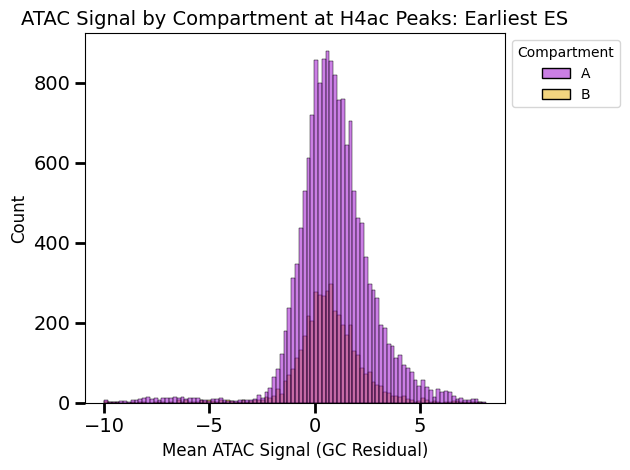

In [ ]:
# Plot histogram of mean ATAC signal (GC residual) at H4ac peaks for the "earliest ES" stage,
# separated by compartment (A/B)

palette = {'A': '#9900cd', 'B': '#e6ac00'}
ax = sns.histplot(data=earliest_ATAC_result_df, x="stat_signal", bins=100, hue="compartment", palette=palette)
plt.title("ATAC Signal by Compartment at H4ac Peaks: Earliest ES", fontsize=14)
plt.xlabel("Mean ATAC Signal (GC Residual)", fontsize=12)
plt.ylabel("Count", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=7)
ax.tick_params(axis='both', which='minor', width=2, length=4)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Compartment")
plt.tight_layout()
plt.savefig('figure_plots/final_figs/Sup6d_H4ac_earliest_ATAC_signal_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

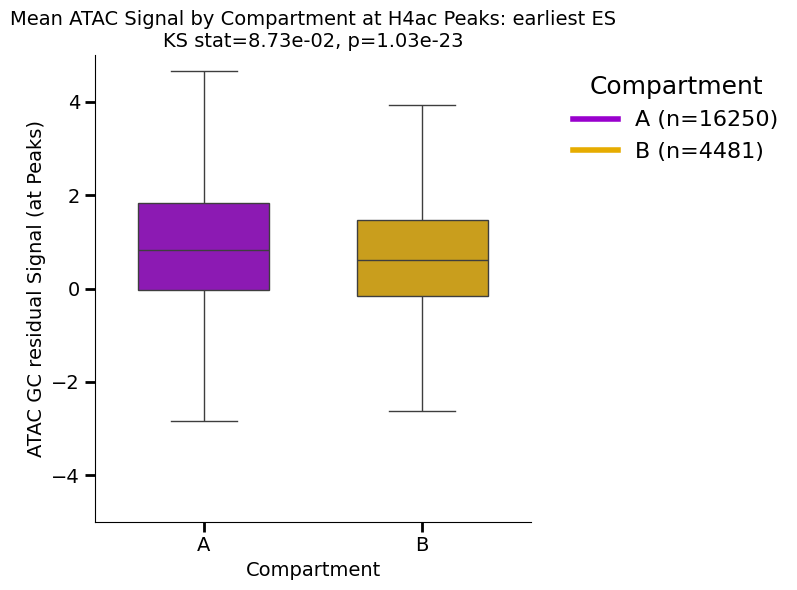

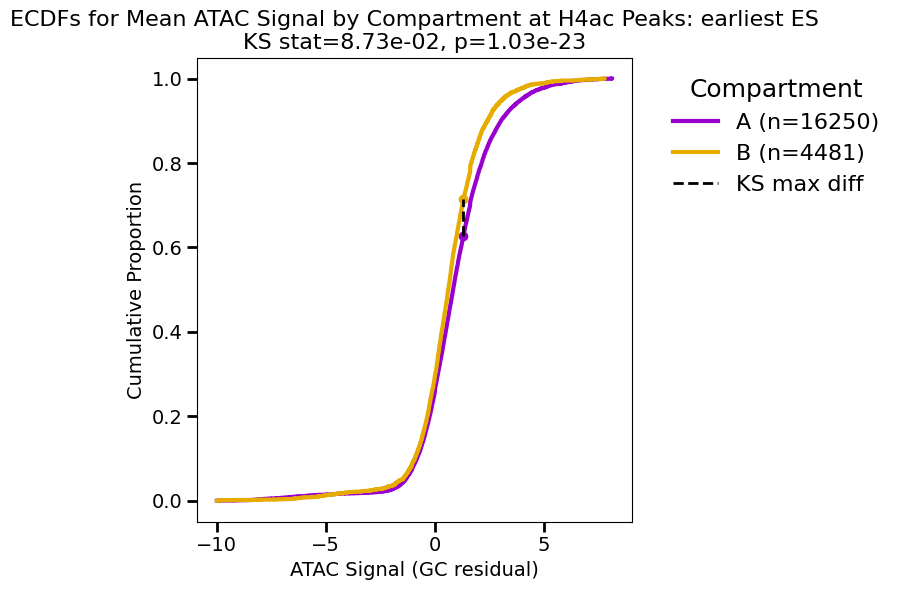

In [11]:
plot_compartment_boxplot(earliest_ATAC_result_df, column="stat_signal", 
                         title="Mean ATAC Signal by Compartment at H4ac Peaks: earliest ES",
                         bins="at Peaks", ylim=(-5,5), threshold=-100, annotate_p=True
                         ,fig1_save_name='figure_plots/final_figs/Sup6d_H4ac_earliest_ATAC_signal_boxplot.png',
                         fig2_save_name='figure_plots/final_figs/Sup6d_H4ac_earliest_ATAC_signal_ECDF.png'
                         )

In [18]:
early_ATAC_result_df = max_signal_by_compartment_parallel(mm39_cs, early_peaks[['chrom', 'start', 'end']], ATAC_early_bg_path, compartment_path, n_jobs=4, stat='mean')

#### Early ES H4ac plots

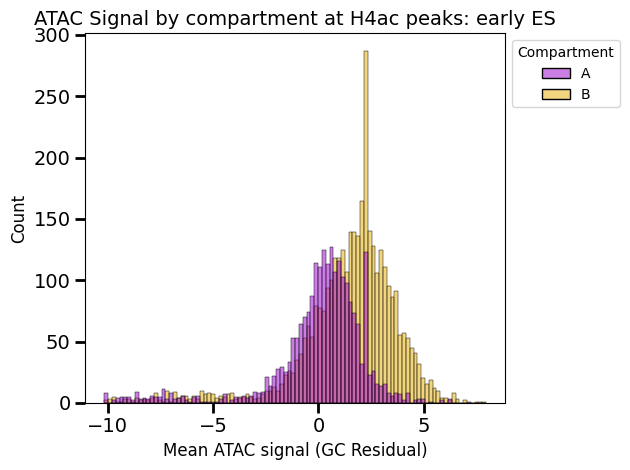

In [19]:
palette = {'A': '#9900cd', 'B': '#e6ac00'}
ax = sns.histplot(data=early_ATAC_result_df, x="stat_signal", bins=100, hue="compartment", palette=palette)
plt.title("ATAC Signal by compartment at H4ac peaks: early ES", fontsize=14)
plt.xlabel('Mean ATAC signal (GC Residual)', fontsize=12)
plt.ylabel("Count", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=7)
ax.tick_params(axis='both', which='minor', width=2, length=4)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Compartment")
plt.tight_layout()
plt.savefig('figure_plots/final_figs/Sup6d_H4ac_early_ATAC_signal_histogram.png')
plt.show()

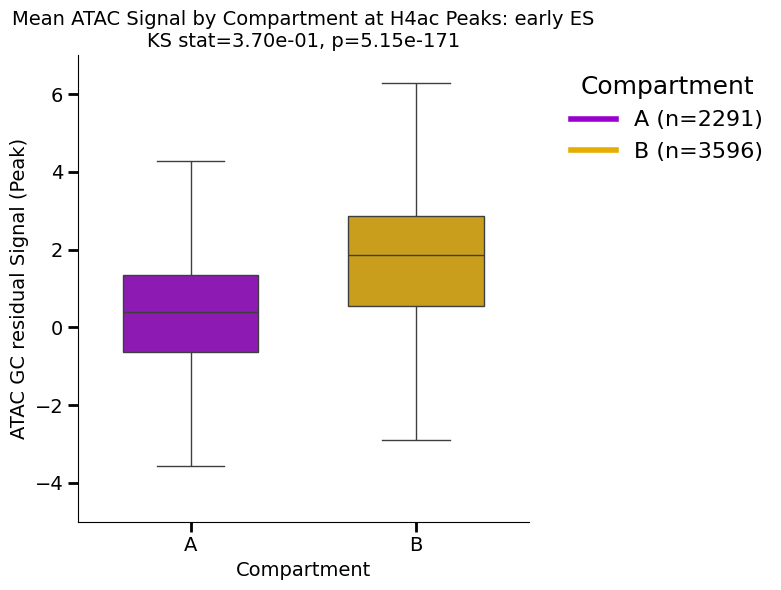

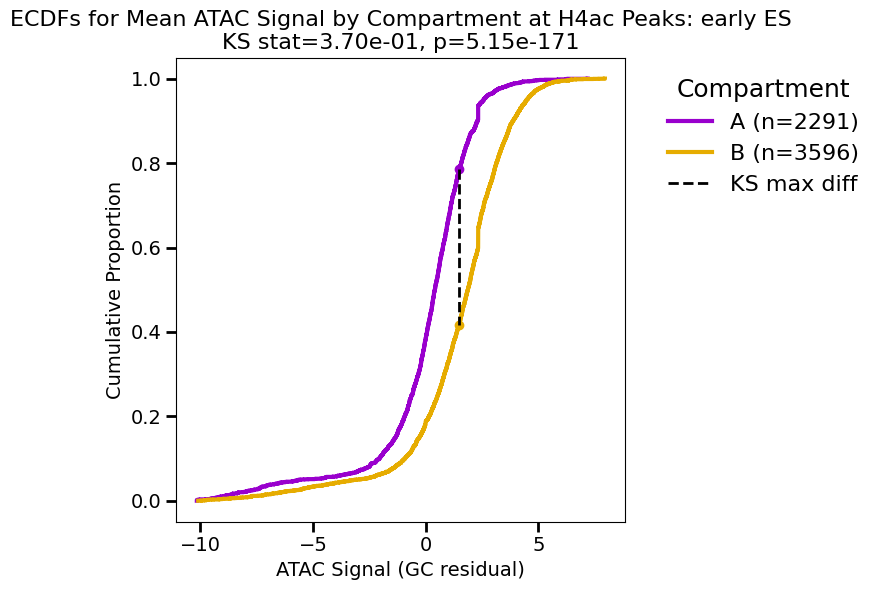

In [34]:
plot_compartment_boxplot(early_ATAC_result_df, column="stat_signal", 
                         title="Mean ATAC Signal by Compartment at H4ac Peaks: early ES", 
                         bins="Peak", ylim=(-5,7), threshold=-100, annotate_p=True,
                         fig1_save_name='figure_plots/final_figs/Sup6d_H4ac_early_ATAC_signal_boxplot.png',
                         fig2_save_name='figure_plots/final_figs/Sup6d_H4ac_early_ATAC_signal_ECDF.png')

### H3k27me3

Same analysis but at H3K27me3 peaks

In [21]:
peaks_dir = "/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/Cut_Tag/A8538/25950R_histone/Peaks"
methyl_earliest_peaks_path = peaks_dir + "/D34_RS_H3K27me3.narrowPeak"
methyl_early_peaks_path = peaks_dir + "/D34_ES_H3K27me3.narrowPeak"

# load peak files as dataframes
methyl_earliest_peaks = pd.read_csv(methyl_earliest_peaks_path, sep='\t', header=None,
                             names=['chrom', 'start', 'end', 'name', 'score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak'])
methyl_early_peaks = pd.read_csv(methyl_early_peaks_path, sep='\t', header=None,
                         names=['chrom', 'start', 'end', 'name', 'score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']) 


In [ ]:
earliest_H3K27me_ATAC_result_df = max_signal_by_compartment_parallel(mm39_cs, methyl_earliest_peaks[['chrom', 'start', 'end']], ATAC_earliest_bg_path, compartment_path, n_jobs=4, stat='mean')

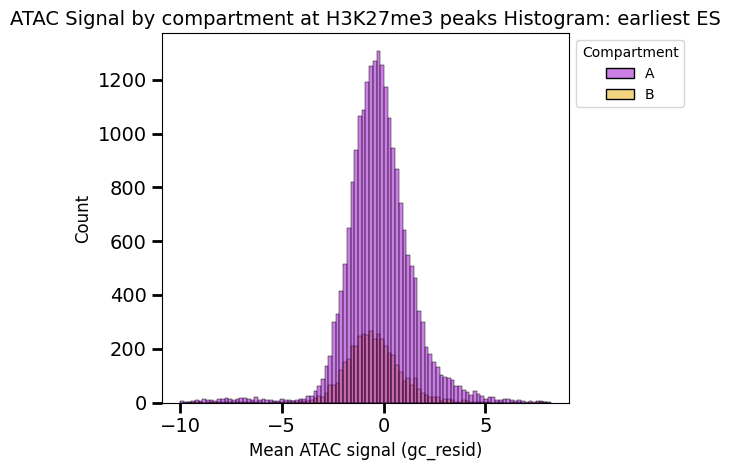

In [23]:
palette = {'A': '#9900cd', 'B': '#e6ac00'}
ax = sns.histplot(data=earliest_H3K27me_ATAC_result_df, x="stat_signal", bins=100, hue="compartment", palette=palette)
plt.title("ATAC Signal by compartment at H3K27me3 peaks Histogram: earliest ES", fontsize=14)
plt.xlabel('Mean ATAC signal (gc_resid)', fontsize=12)
plt.ylabel("Count", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=7)
ax.tick_params(axis='both', which='minor', width=2, length=4)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Compartment")
plt.tight_layout()
plt.savefig('figure_plots/final_figs/Sup6d_H3K27me3_earliest_ATAC_signal_histogram.png')
plt.show()

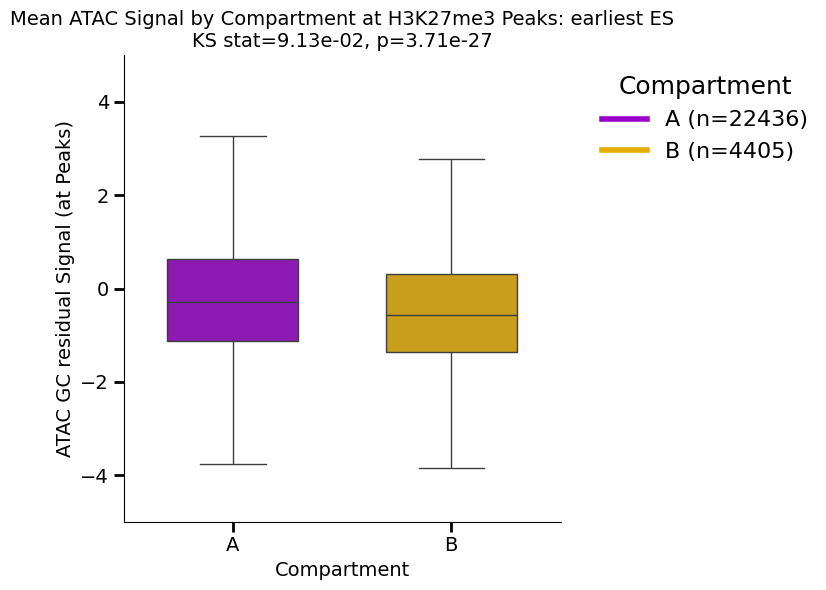

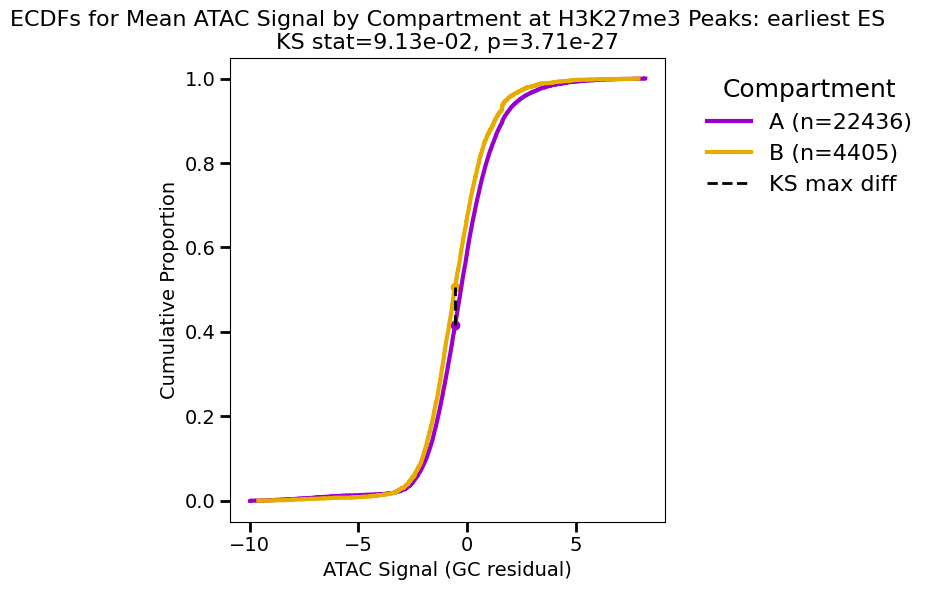

In [35]:
plot_compartment_boxplot(earliest_H3K27me_ATAC_result_df, column="stat_signal", 
                         title="Mean ATAC Signal by Compartment at H3K27me3 Peaks: earliest ES", 
                         bins="at Peaks", ylim=(-5,5), threshold=-100, annotate_p=True,
                         fig1_save_name='figure_plots/final_figs/Sup6d_H3K27me3_earliest_ATAC_signal_boxplot.png',
                         fig2_save_name='figure_plots/final_figs/Sup6d_H3K27me3_earliest_ATAC_signal_ECDF.png')

In [25]:
early_H3K27me_ATAC_result_df = max_signal_by_compartment_parallel(mm39_cs, methyl_early_peaks[['chrom', 'start', 'end']], ATAC_early_bg_path, compartment_path, n_jobs=4, stat='mean')


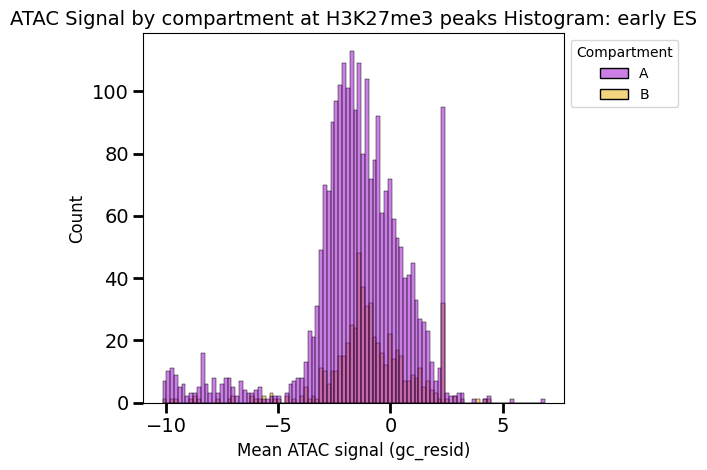

In [26]:
palette = {'A': '#9900cd', 'B': '#e6ac00'}
ax = sns.histplot(data=early_H3K27me_ATAC_result_df, x="stat_signal", bins=100, hue="compartment", palette=palette)
plt.title("ATAC Signal by compartment at H3K27me3 peaks Histogram: early ES", fontsize=14)
plt.xlabel('Mean ATAC signal (gc_resid)', fontsize=12)
plt.ylabel("Count", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=7)
ax.tick_params(axis='both', which='minor', width=2, length=4)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Compartment")
plt.tight_layout()
plt.savefig('figure_plots/final_figs/Sup6d_H3K27me3_early_ATAC_signal_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

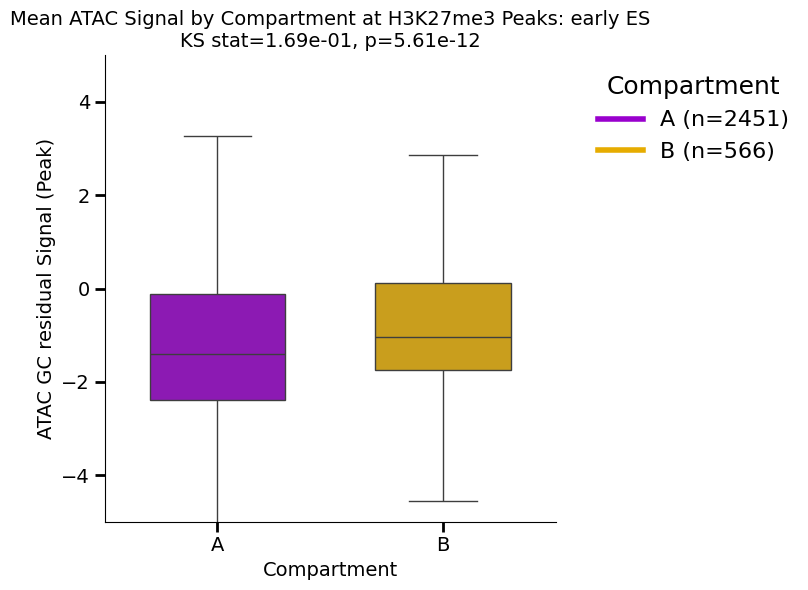

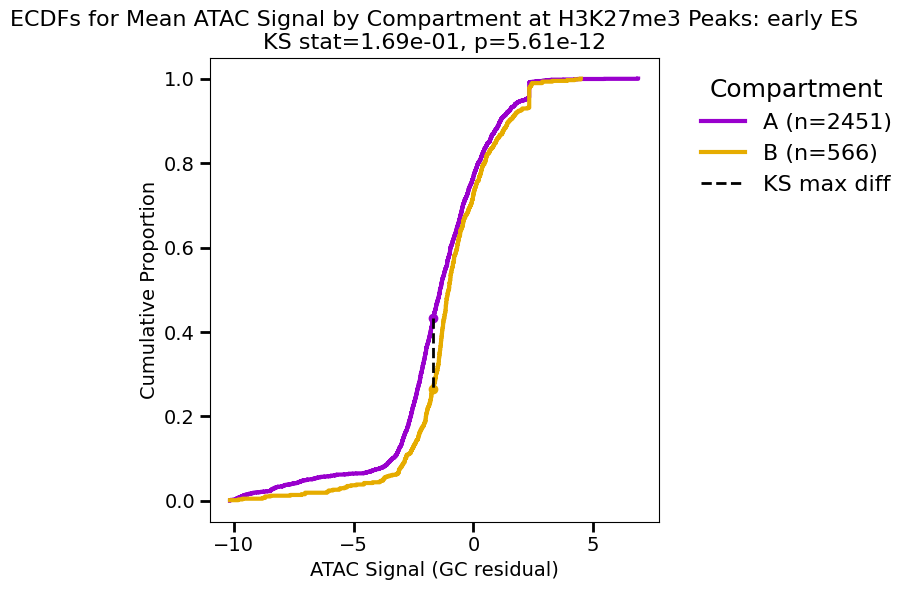

In [36]:
plot_compartment_boxplot(early_H3K27me_ATAC_result_df, column="stat_signal", 
                         title="Mean ATAC Signal by Compartment at H3K27me3 Peaks: early ES", 
                         bins="Peak", ylim=(-5,5), threshold=-100, annotate_p=True,
                         fig1_save_name='figure_plots/final_figs/Sup6d_H3K27me3_early_ATAC_signal_boxplot.png',
                         fig2_save_name='figure_plots/final_figs/Sup6d_H3K27me3_early_ATAC_signal_ECDF.png')